Вот ссылка на датасет: [Steam Games Dataset](https://www.kaggle.com/datasets/fronkongames/steam-games-dataset)

Будем решать задачу по предсказанию примерного числа игроков ("Estomated owners").

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('datasets/games.csv', low_memory=False)
arr_of_eo = np.array(df['Release date'])
arr_of_ccu = np.array(df['Estimated owners'])
arr_of_price = np.array(df['Required age'])
df.head(2)

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
20200,Galactic Bowling,"Oct 21, 2008",0 - 20000,0,0,19.99,0,0,Galactic Bowling is an exaggerated and stylize...,['English'],[],NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,http://www.galacticbowling.net,NaN,NaN,True,False,False,0,NaN,0,6,11,NaN,30,0,NaN,0,0,0,0,Perpetual FX Creative,Perpetual FX Creative,"Single-player,Multi-player,Steam Achievements,...","Casual,Indie,Sports","Indie,Casual,Sports,Bowling",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
655370,Train Bandit,"Oct 12, 2017",0 - 20000,0,0,0.99,0,0,THE LAW!! Looks to be a showdown atop a train....,"['English', 'French', 'Italian', 'German', 'Sp...",[],NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,http://trainbandit.com,NaN,support@rustymoyher.com,True,True,False,0,NaN,0,53,5,NaN,12,0,NaN,0,0,0,0,Rusty Moyher,Wild Rooster,"Single-player,Steam Achievements,Full controll...","Action,Indie","Indie,Action,Pixel Graphics,2D,Retro,Arcade,Sc...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...


Видим, что датасет просто балдеж. Без мата даже сложно описать мои эмоции и кол-во разных попыток это пофиксить. Ну ладно...

In [4]:
df['Estimated owners'] = arr_of_eo
df['Peak CCU'] = arr_of_ccu
df['Price'] = arr_of_price

df.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
20200,Galactic Bowling,"Oct 21, 2008",0 - 20000,0 - 20000,0,19.99,19.99,0,Galactic Bowling is an exaggerated and stylize...,['English'],[],NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,http://www.galacticbowling.net,NaN,NaN,True,False,False,0,NaN,0,6,11,NaN,30,0,NaN,0,0,0,0,Perpetual FX Creative,Perpetual FX Creative,"Single-player,Multi-player,Steam Achievements,...","Casual,Indie,Sports","Indie,Casual,Sports,Bowling",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
655370,Train Bandit,"Oct 12, 2017",0 - 20000,0 - 20000,0,0.99,0.99,0,THE LAW!! Looks to be a showdown atop a train....,"['English', 'French', 'Italian', 'German', 'Sp...",[],NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,http://trainbandit.com,NaN,support@rustymoyher.com,True,True,False,0,NaN,0,53,5,NaN,12,0,NaN,0,0,0,0,Rusty Moyher,Wild Rooster,"Single-player,Steam Achievements,Full controll...","Action,Indie","Indie,Action,Pixel Graphics,2D,Retro,Arcade,Sc...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
1732930,Jolt Project,"Nov 17, 2021",0 - 20000,0 - 20000,0,4.99,4.99,0,Jolt Project: The army now has a new robotics ...,"['English', 'Portuguese - Brazil']",[],NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,NaN,NaN,ramoncampiaof31@gmail.com,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,Campião Games,Campião Games,Single-player,"Action,Adventure,Indie,Strategy",NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
1355720,Henosis™,"Jul 23, 2020",0 - 20000,0 - 20000,0,5.99,5.99,0,HENOSIS™ is a mysterious 2D Platform Puzzler w...,"['English', 'French', 'Italian', 'German', 'Sp...",[],NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,https://henosisgame.com/,https://henosisgame.com/,info@henosisgame.com,True,True,True,0,NaN,0,3,0,NaN,0,0,NaN,0,0,0,0,Odd Critter Games,Odd Critter Games,"Single-player,Full controller support","Adventure,Casual,Indie","2D Platformer,Atmospheric,Surreal,Mystery,Puzz...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
1139950,Two Weeks in Painland,"Feb 3, 2020",0 - 20000,0 - 20000,0,0.00,0.00,0,ABOUT THE GAME Play as a hacker who has arrang...,"['English', 'Spanish - Spain']",[],NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,https://www.unusual-games.com/home/,https://www.unusual-games.com/contact/,welistentoyou@unusual-games.com,True,True,False,0,NaN,0,50,8,NaN,17,0,This Game may contain content not appropriate ...,0,0,0,0,Unusual Games,Unusual Games,"Single-player,Steam Achievements","Adventure,Indie","Indie,Adventure,Nudity,Violent,Sexual Content,...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 111452 entries, 20200 to 3183790
Data columns (total 39 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AppID                       111446 non-null  object 
 1   Name                        111452 non-null  object 
 2   Release date                111452 non-null  object 
 3   Estimated owners            111452 non-null  object 
 4   Peak CCU                    111452 non-null  int64  
 5   Required age                111452 non-null  float64
 6   Price                       111452 non-null  float64
 7   DiscountDLC count           111452 non-null  int64  
 8   About the game              104969 non-null  object 
 9   Supported languages         111452 non-null  object 
 10  Full audio languages        111452 non-null  object 
 11  Reviews                     10624 non-null   object 
 12  Header image                111452 non-null  object 
 13  Website       

---------------

Избавимся от очевидно ненужных столбцов

In [6]:
df.columns

Index(['AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'DiscountDLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
       'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies'],
      dtype='object')

In [7]:
df = df.drop(columns=['AppID', 'Name','Required age', 'DiscountDLC count', 'About the game', 'Supported languages', 
                     'Full audio languages', 'Reviews', 'Tags', 'Screenshots', 'Movies', 
                     'Header image', 'Website', 'Support url', 'Support email', 'Notes', 'Metacritic url', 'Score rank', 'Release date'])

In [8]:
df.columns

Index(['Estimated owners', 'Peak CCU', 'Price', 'Windows', 'Mac', 'Linux',
       'Metacritic score', 'User score', 'Positive', 'Negative',
       'Achievements', 'Recommendations', 'Average playtime forever',
       'Average playtime two weeks', 'Median playtime forever',
       'Median playtime two weeks', 'Developers', 'Publishers', 'Categories',
       'Genres'],
      dtype='object')

In [9]:
df.head(10)

,Estimated owners,Peak CCU,Price,Windows,Mac,Linux,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres
20200,0 - 20000,0,19.99,True,False,False,0,0,6,11,30,0,0,0,0,0,Perpetual FX Creative,Perpetual FX Creative,"Single-player,Multi-player,Steam Achievements,...","Casual,Indie,Sports"
655370,0 - 20000,0,0.99,True,True,False,0,0,53,5,12,0,0,0,0,0,Rusty Moyher,Wild Rooster,"Single-player,Steam Achievements,Full controll...","Action,Indie"
1732930,0 - 20000,0,4.99,True,False,False,0,0,0,0,0,0,0,0,0,0,Campião Games,Campião Games,Single-player,"Action,Adventure,Indie,Strategy"
1355720,0 - 20000,0,5.99,True,True,True,0,0,3,0,0,0,0,0,0,0,Odd Critter Games,Odd Critter Games,"Single-player,Full controller support","Adventure,Casual,Indie"
1139950,0 - 20000,0,0.00,True,True,False,0,0,50,8,17,0,0,0,0,0,Unusual Games,Unusual Games,"Single-player,Steam Achievements","Adventure,Indie"
1469160,50000 - 100000,68,0.00,True,False,False,0,0,87,49,0,0,0,0,0,0,7Road,7Road,"Single-player,Multi-player,MMO,PvP,Online PvP,...","Adventure,Casual,Free to Play,Massively Multip..."
1659180,0 - 20000,3,10.99,True,False,False,0,0,21,7,62,0,0,0,0,0,MAKSIM VOLKAU,MAKSIM VOLKAU,"Single-player,Steam Achievements,Steam Cloud","Indie,Strategy"
1968760,0 - 20000,2,9.99,True,False,False,0,0,0,0,0,0,0,0,0,0,magnussoft,magnussoft,"Single-player,Steam Cloud",Casual
1178150,0 - 20000,1,14.99,True,False,False,0,0,76,6,25,0,0,0,0,0,Growing Seeds,"CFK Co., Ltd.","Single-player,Steam Achievements,Full controll...","Adventure,RPG,Simulation,Strategy"
320150,50000 - 100000,0,3.99,True,True,True,0,0,225,45,32,0,703,0,782,0,ONE MORE LEVEL,ONE MORE LEVEL,"Single-player,Steam Achievements,Steam Trading...","Action,Adventure,Indie"


------------------

Удалим строки с нулями

In [10]:
df.isna().sum()

Estimated owners                 0
Peak CCU                         0
Price                            0
Windows                          0
Mac                              0
Linux                            0
Metacritic score                 0
User score                       0
Positive                         0
Negative                         0
Achievements                     0
Recommendations                  0
Average playtime forever         0
Average playtime two weeks       0
Median playtime forever          0
Median playtime two weeks        0
Developers                    6475
Publishers                    6778
Categories                    7566
Genres                        6440
dtype: int64

In [11]:
df = df.dropna()

In [12]:
df.isna().sum()

Estimated owners              0
Peak CCU                      0
Price                         0
Windows                       0
Mac                           0
Linux                         0
Metacritic score              0
User score                    0
Positive                      0
Negative                      0
Achievements                  0
Recommendations               0
Average playtime forever      0
Average playtime two weeks    0
Median playtime forever       0
Median playtime two weeks     0
Developers                    0
Publishers                    0
Categories                    0
Genres                        0
dtype: int64

In [13]:
df.shape

(103219, 20)

------------------

In [14]:
df.to_csv(
    'datasets/games_new.csv'
)

* поправить estimated owners
* поправить виндовс мак и линукс
* поправить жанры и категории

Изменим данные в колонке "Estimated owners"

In [15]:
df['Estimated owners'] = df['Estimated owners'].str.extract(r'(\d+)$').astype(int)
df.head()

,Estimated owners,Peak CCU,Price,Windows,Mac,Linux,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres
20200,20000,0,19.99,True,False,False,0,0,6,11,30,0,0,0,0,0,Perpetual FX Creative,Perpetual FX Creative,"Single-player,Multi-player,Steam Achievements,...","Casual,Indie,Sports"
655370,20000,0,0.99,True,True,False,0,0,53,5,12,0,0,0,0,0,Rusty Moyher,Wild Rooster,"Single-player,Steam Achievements,Full controll...","Action,Indie"
1732930,20000,0,4.99,True,False,False,0,0,0,0,0,0,0,0,0,0,Campião Games,Campião Games,Single-player,"Action,Adventure,Indie,Strategy"
1355720,20000,0,5.99,True,True,True,0,0,3,0,0,0,0,0,0,0,Odd Critter Games,Odd Critter Games,"Single-player,Full controller support","Adventure,Casual,Indie"
1139950,20000,0,0.00,True,True,False,0,0,50,8,17,0,0,0,0,0,Unusual Games,Unusual Games,"Single-player,Steam Achievements","Adventure,Indie"


In [16]:
df['Windows'] = df['Windows'].astype(int)
df['Mac'] = df['Mac'].astype(int)
df['Linux'] = df['Linux'].astype(int)
df.head()

,Estimated owners,Peak CCU,Price,Windows,Mac,Linux,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres
20200,20000,0,19.99,1,0,0,0,0,6,11,30,0,0,0,0,0,Perpetual FX Creative,Perpetual FX Creative,"Single-player,Multi-player,Steam Achievements,...","Casual,Indie,Sports"
655370,20000,0,0.99,1,1,0,0,0,53,5,12,0,0,0,0,0,Rusty Moyher,Wild Rooster,"Single-player,Steam Achievements,Full controll...","Action,Indie"
1732930,20000,0,4.99,1,0,0,0,0,0,0,0,0,0,0,0,0,Campião Games,Campião Games,Single-player,"Action,Adventure,Indie,Strategy"
1355720,20000,0,5.99,1,1,1,0,0,3,0,0,0,0,0,0,0,Odd Critter Games,Odd Critter Games,"Single-player,Full controller support","Adventure,Casual,Indie"
1139950,20000,0,0.00,1,1,0,0,0,50,8,17,0,0,0,0,0,Unusual Games,Unusual Games,"Single-player,Steam Achievements","Adventure,Indie"


In [17]:
all_categories = df['Categories'].str.split(',\s*').explode()
top_15_categories = all_categories.value_counts().head(15).index.tolist()

for category in top_15_categories:
    df[f'{category}'] = df['Categories'].str.contains(category, case=False, regex=False).astype(int)

df.drop('Categories', axis=1, inplace=True)

In [18]:
df.head()

,Estimated owners,Peak CCU,Price,Windows,Mac,Linux,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Genres,Single-player,Steam Achievements,Steam Cloud,Full controller support,Multi-player,Family Sharing,Partial Controller Support,PvP,Steam Trading Cards,Co-op,Online PvP,Steam Leaderboards,Remote Play Together,Shared/Split Screen,Online Co-op
20200,20000,0,19.99,1,0,0,0,0,6,11,30,0,0,0,0,0,Perpetual FX Creative,Perpetual FX Creative,"Casual,Indie,Sports",1,1,0,0,1,0,1,0,0,0,0,0,0,0,0
655370,20000,0,0.99,1,1,0,0,0,53,5,12,0,0,0,0,0,Rusty Moyher,Wild Rooster,"Action,Indie",1,1,0,1,0,0,0,0,0,0,0,1,0,0,0
1732930,20000,0,4.99,1,0,0,0,0,0,0,0,0,0,0,0,0,Campião Games,Campião Games,"Action,Adventure,Indie,Strategy",1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1355720,20000,0,5.99,1,1,1,0,0,3,0,0,0,0,0,0,0,Odd Critter Games,Odd Critter Games,"Adventure,Casual,Indie",1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1139950,20000,0,0.00,1,1,0,0,0,50,8,17,0,0,0,0,0,Unusual Games,Unusual Games,"Adventure,Indie",1,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [19]:
all_genres = df['Genres'].str.split(',\s*').explode()
top_15_genres = all_genres.value_counts().head(15).index.tolist()

for genre in top_15_genres:
    df[f'{genre}'] = df['Genres'].str.contains(genre, case=False, regex=False).astype(int)

df.drop('Genres', axis=1, inplace=True)

In [20]:
df = df[df['Metacritic score'] != 0]

In [21]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Estimated owners,3958.0,1.169591e+06,5.414543e+06,0.0,50000.000,200000.00,500000.00,2.000000e+08
Peak CCU,3958.0,1.530783e+03,2.245884e+04,0.0,1.000,7.00,67.00,8.721380e+05
Price,3958.0,1.530751e+01,1.210173e+01,0.0,7.475,13.49,19.99,6.999000e+01
Windows,3958.0,1.000000e+00,0.000000e+00,1.0,1.000,1.00,1.00,1.000000e+00
Mac,3958.0,3.888327e-01,4.875468e-01,0.0,0.000,0.00,1.00,1.000000e+00
Linux,3958.0,2.673067e-01,4.426097e-01,0.0,0.000,0.00,1.00,1.000000e+00
Metacritic score,3958.0,7.303638e+01,1.060782e+01,8.0,68.000,75.00,80.00,9.700000e+01
User score,3958.0,2.400202e-02,1.510030e+00,0.0,0.000,0.00,0.00,9.500000e+01
Positive,3958.0,1.244683e+04,1.059362e+05,0.0,223.000,926.50,4476.75,5.764420e+06
Negative,3958.0,1.671541e+03,1.459525e+04,0.0,60.000,196.00,733.00,7.666770e+05


In [22]:
df.to_csv(
    'datasets/games_newest.csv'
)

-------------

Проведем предварительный анализ.

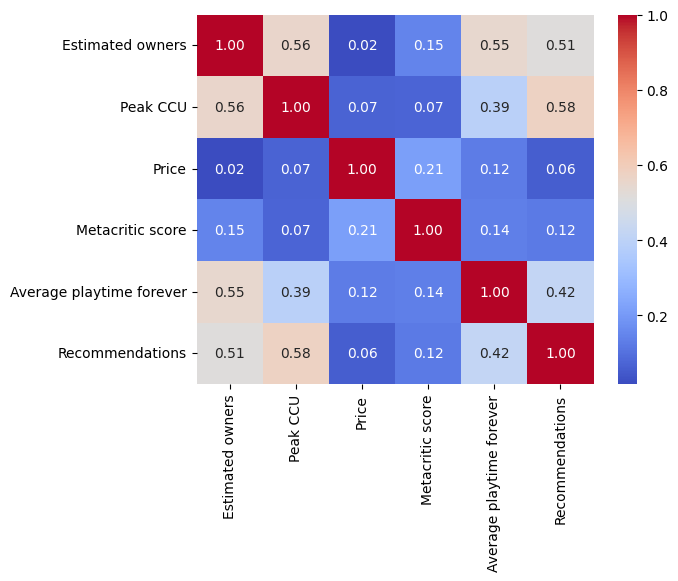

In [23]:
corr_matrix = df[['Estimated owners', 'Peak CCU', 'Price', 'Metacritic score', 'Average playtime forever', 'Recommendations']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

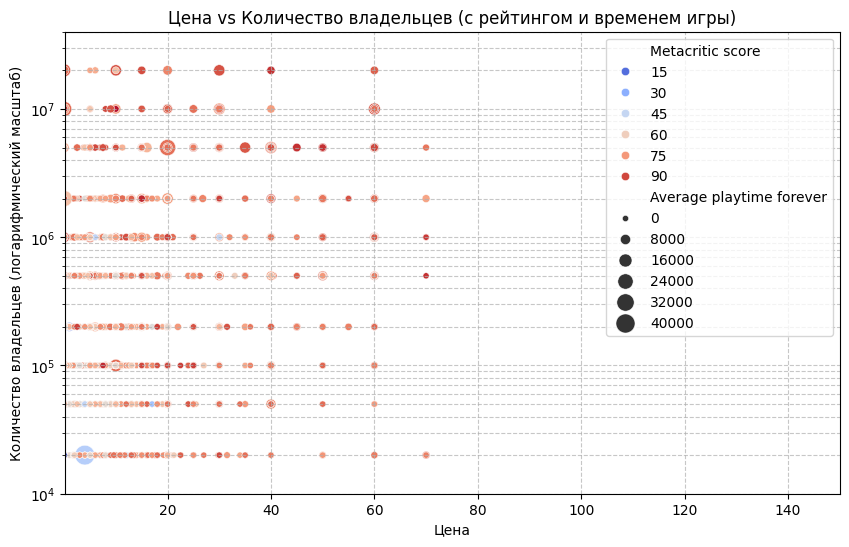

In [24]:
df_filtered = df[(df['Estimated owners'] <= 2e7) & (df['Estimated owners'] > 20) & (df['Price'] < 400) & (df['Metacritic score'] > 0)]

plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(data=df_filtered, x='Price', y='Estimated owners', hue='Metacritic score', 
                         size='Average playtime forever', sizes=(20, 200), palette='coolwarm')

plt.yscale('log')

plt.ylim(1e4, 4e7)
plt.xlim(0.1, 150)

plt.title('Цена vs Количество владельцев (с рейтингом и временем игры)')
plt.xlabel('Цена')
plt.ylabel('Количество владельцев (логарифмический масштаб)')

plt.grid(True, which="both", ls="--", alpha=0.7)

plt.show()

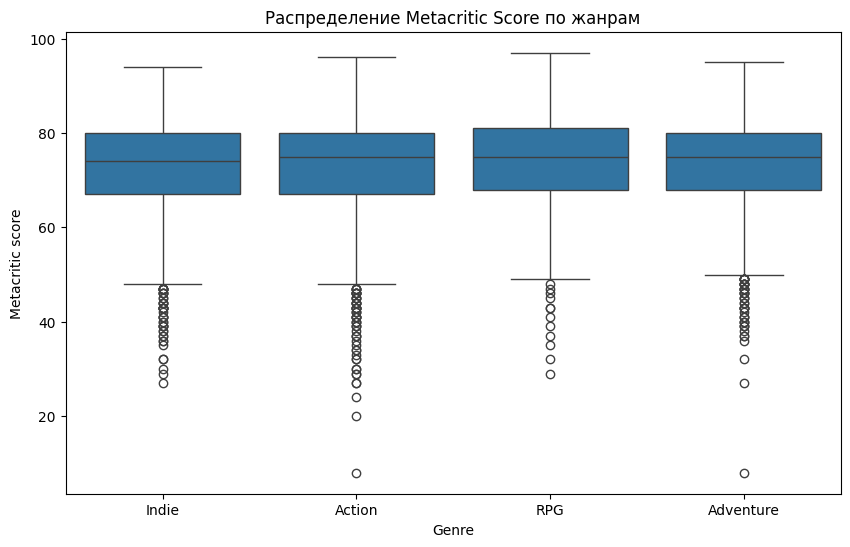

In [25]:
genres = ['Indie', 'Action', 'RPG', 'Adventure']
df_melted = df_filtered.melt(id_vars=['Metacritic score'], value_vars=genres, 
                    var_name='Genre', value_name='Present')
df_melted = df_melted[df_melted['Present'] == 1]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_melted, x='Genre', y='Metacritic score')
plt.title('Распределение Metacritic Score по жанрам')
plt.show()

/var/folders/h6/fd4m_69x3d7dxxd2k92dltp40000gn/T/ipykernel_36813/734735157.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_features, x='Count', y='Feature', palette='pastel')


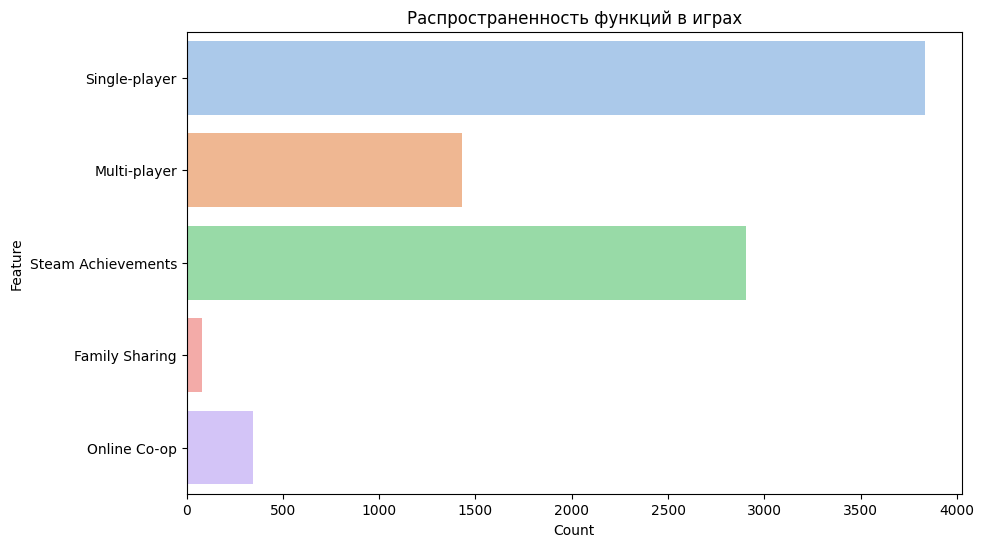

In [26]:
features = ['Single-player', 'Multi-player', 'Steam Achievements', 'Family Sharing', 'Online Co-op']
df_features = df[features].sum().reset_index()
df_features.columns = ['Feature', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(data=df_features, x='Count', y='Feature', palette='pastel')
plt.title('Распространенность функций в играх')
plt.show()

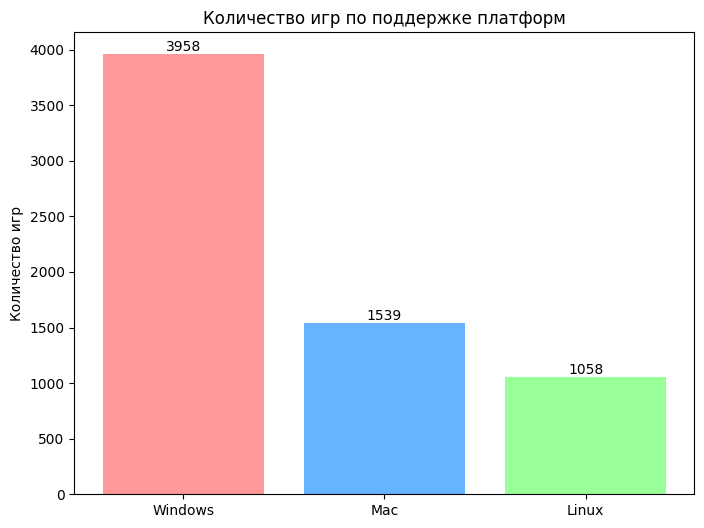

In [27]:
platforms = ['Windows', 'Mac', 'Linux']
platform_counts = (df[platforms] >= 1).sum()

plt.figure(figsize=(8, 6))
plt.bar(platforms, platform_counts, color=['#ff9999', '#66b3ff', '#99ff99'])
plt.title('Количество игр по поддержке платформ')
plt.ylabel('Количество игр')
for i, v in enumerate(platform_counts):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.show()

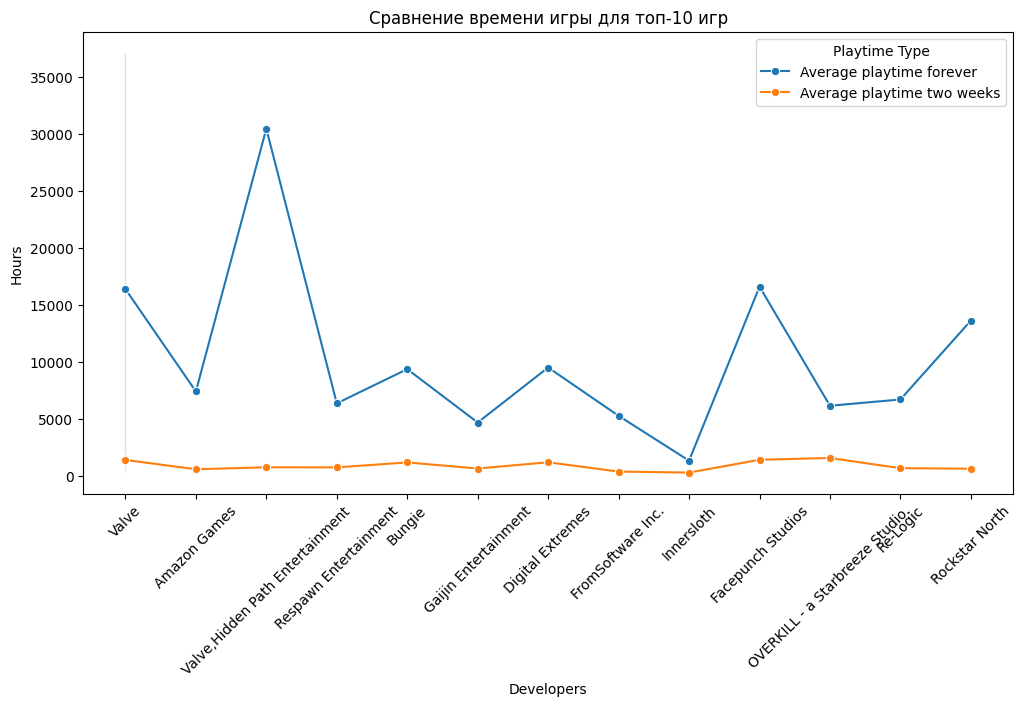

In [28]:
top_games = df.nlargest(15, 'Estimated owners')
top_games_melted = top_games.melt(id_vars=['Developers'], 
                                   value_vars=['Average playtime forever', 'Average playtime two weeks'], 
                                   var_name='Playtime Type', value_name='Hours')

plt.figure(figsize=(12, 6))
sns.lineplot(data=top_games_melted, x='Developers', y='Hours', hue='Playtime Type', marker='o')
plt.title('Сравнение времени игры для топ-10 игр')
plt.xticks(rotation=45)
plt.show()

/Users/damirhabibulin/Library/Python/3.9/lib/python/site-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/Users/damirhabibulin/Library/Python/3.9/lib/python/site-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/Users/damirhabibulin/Library/Python/3.9/lib/python/site-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/Users/damirhabibulin/Library/Python/3.9/lib/python/site-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/Users/damirhabibulin/Library/Python/3.9/lib/python/site-packages/seaborn/axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)


<Figure size 100x100 with 0 Axes>

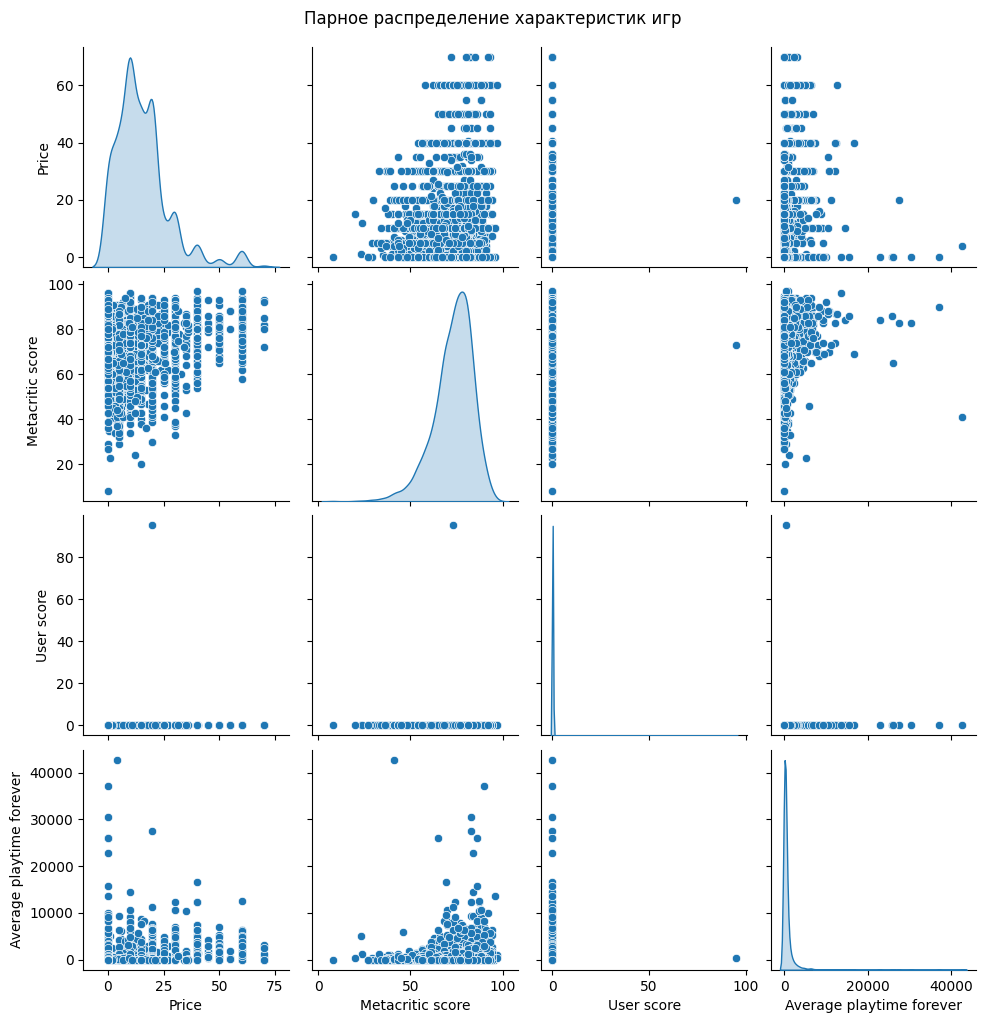

In [29]:
plt.figure(figsize=(1,1))
sns.pairplot(df[['Price', 'Metacritic score', 'User score', 'Average playtime forever']], 
             diag_kind='kde', palette='husl')
plt.suptitle('Парное распределение характеристик игр', y=1.02)
plt.show()

------------------

Попробуем решить задачу предсказания количества игроков.

Начнем с PCA для поиска главных компонент

In [30]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

numeric_features = [
    'Estimated owners', 'Peak CCU', 'Price', 'Metacritic score', 
    'User score', 'Average playtime forever', 'Average playtime two weeks', 
    'Median playtime forever', 'Median playtime two weeks', 'Recommendations'
]

numeric_features = [col for col in numeric_features if col in df.columns]

X = df[numeric_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=5)  # Уменьшаем до 5 компонент
X_pca = pca.fit_transform(X_scaled)

Теперь обучим модельку на Х_pca. Используем CatBoost, потому что это хорошая штука, так еще и с категориальными признаками умеет работать

In [31]:
from sklearn.metrics import mean_squared_error, r2_score
from catboost import CatBoostRegressor
from catboost import Pool
from sklearn.model_selection import train_test_split

target = 'Estimated owners'
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, shuffle=True, random_state=42)

train_pool = Pool(data=X_train, label=y_train)
model = CatBoostRegressor(iterations=100, learning_rate=0.1, loss_function='RMSE', verbose=0)
model.fit(train_pool)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f'RMSE на тестовом наборе: {rmse:.4f}')
print(f'R² на тестовом наборе: {r2:.4f}')

RMSE на тестовом наборе: 3132004.3782
R² на тестовом наборе: 0.4802


Попробуем посмотреть feature_importance с помощью того же CatBoost, и обучить модельку на новых признаках

                    Feature Id  Importances
0                     Positive    23.858001
1                     Negative    19.365554
2                     Peak CCU     8.291108
3                 Free to Play     7.372481
4              Recommendations     7.147978
5                Single-player     6.078253
6     Average playtime forever     4.052664
7                 Achievements     3.296944
8             Metacritic score     3.144231
9      Median playtime forever     2.841945
10                Online Co-op     1.651844
11                       Price     1.442223
12   Median playtime two weeks     1.324174
13                  Developers     1.296831
14                         Mac     1.114207
15                  Online PvP     1.072051
16                    Strategy     1.054472
17                Free To Play     0.752180
18                         PvP     0.654355
19                       Co-op     0.576290
20  Average playtime two weeks     0.566958
21                 Steam Cloud  

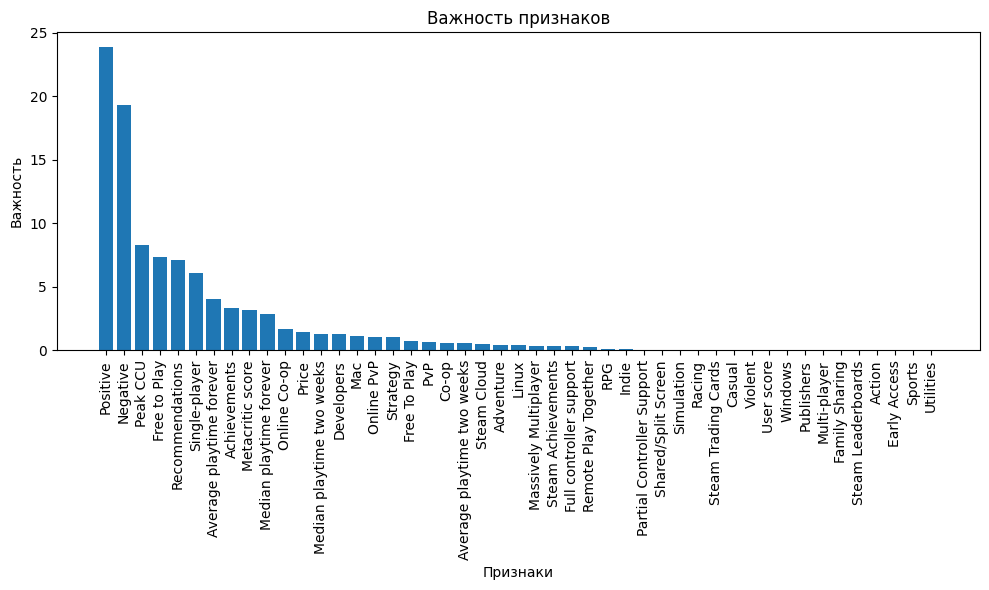

In [32]:
features = [col for col in df.columns if col != target]

X = df[features]
y = df[target]

cat_features = ['Developers', 'Publishers']  # категориальные признаки

model = CatBoostRegressor(iterations=100, learning_rate=0.1, cat_features=cat_features, verbose=0)
model.fit(X, y)

feature_importance = model.get_feature_importance(prettified=True)
cat_features = ['Publishers']
print(feature_importance)

important_features = feature_importance[feature_importance['Importances'] > 5]['Feature Id'].tolist()
X_reduced = X[important_features]

plt.figure(figsize=(10, 6))
plt.bar(feature_importance['Feature Id'], feature_importance['Importances'])
plt.xticks(ticks=range(len(feature_importance['Feature Id'])), labels=feature_importance['Feature Id'], rotation=90)
plt.title('Важность признаков')
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.tight_layout()
plt.show()

Можно заметить, что наша модель работает лучше со всеми признаками. Видимо потому что датасет очень большой и никакого переобучения не происходит, и шум никак не влият на предсказания.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.3, shuffle=True, random_state=42
)

model1 = CatBoostRegressor(iterations=500, learning_rate=0.01, verbose=50)
model1.fit(X_train, y_train, eval_set=(X_test, y_test))
predictions = model1.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)
print(f'RMSE на уменьшенной модели: {rmse}')
print(f'R² на уменьшенной модели: {r2:.4f}')

0:	learn: 5792316.6331573	test: 4336932.5950535	best: 4336932.5950535 (0)	total: 717us	remaining: 358ms
50:	learn: 4840020.9133349	test: 3897491.8729015	best: 3897491.8729015 (50)	total: 29.3ms	remaining: 258ms
100:	learn: 4128595.4169728	test: 3618083.9951854	best: 3618083.9951854 (100)	total: 55.6ms	remaining: 220ms
150:	learn: 3605294.9213849	test: 3437201.7961876	best: 3437201.7961876 (150)	total: 87.5ms	remaining: 202ms
200:	learn: 3205023.7278290	test: 3313036.9222029	best: 3313036.9222029 (200)	total: 115ms	remaining: 170ms
250:	learn: 2879958.5746948	test: 3235315.4440859	best: 3235315.4440859 (250)	total: 143ms	remaining: 141ms
300:	learn: 2610302.1895405	test: 3156590.2529587	best: 3156590.2529587 (300)	total: 169ms	remaining: 112ms
350:	learn: 2396675.8880379	test: 3118177.1497288	best: 3118131.6734709 (349)	total: 195ms	remaining: 82.6ms
400:	learn: 2220451.6612556	test: 3069496.4690718	best: 3069496.4690718 (400)	total: 221ms	remaining: 54.6ms
450:	learn: 2077597.2611614	t

Можно заметить на самом деле что происходит переобучение, да и вообще дела не очень обстоят

Посмотрим, что покажет нам Gradient Boosting Regressor с 100 деревьями.

In [34]:
from sklearn.ensemble import GradientBoostingRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.3, shuffle=True, random_state=42
)

gb_model = GradientBoostingRegressor(n_estimators=100)
gb_model.fit(X_train, y_train)
y_pred = gb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f'RMSE на уменьшенной модели: {rmse}')
print(f'R² на уменьшенной модели: {r2:.4f}')

RMSE на уменьшенной модели: 1376930.8231491789
R² на уменьшенной модели: 0.8995


Тут я подумал, что может быть надо не 100, а какое-то другое количество, и вспомнил про GridSearch

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.3, shuffle=True, random_state=42
)

gb_model = GradientBoostingRegressor(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 150, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10]
}

grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    cv=10,  # 5 фолдов для кросс-валидации
    scoring='r2',  # Оптимизируем по R²
    n_jobs=-1,  # Используем все доступные ядра процессора
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Лучшее значение n_estimators: {grid_search.best_params_['n_estimators']}")
print(f"Лучший R² на кросс-валидации: {grid_search.best_score_:.4f}")

# Обучаем модель с лучшими параметрами на всех тренировочных данных
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f'RMSE на тестовом наборе: {rmse:.4f}')
print(f'R² на тестовом наборе: {r2:.4f}')

Fitting 10 folds for each of 60 candidates, totalling 600 fits
Лучшее значение n_estimators: 150
Лучший R² на кросс-валидации: 0.6124
RMSE на тестовом наборе: 2535703.7786
R² на тестовом наборе: 0.6593


Вообщем-то дела прям не очень, даже плакать хочется, но ничего не поделать...

-------------

Попробуем решить эту задачу, посмотрев на нее как на задачу классификации. У нас будет 7 классов количества игроков. Мы будем предсказывать какому классу игра принадлежит.

In [35]:
df_user = pd.read_csv('datasets/games_newest.csv', index_col=0)

print(f"Исходные значения 'Estimated owners': min={df_user['Estimated owners'].min()}, max={df_user['Estimated owners'].max()}")
max_owners_value = df_user['Estimated owners'].max()

bins = [
    -1,                     # для игр с 0 владельцами (если такие есть и попали в df_user)
    20000,                  # Уровень 1: до 20,000
    100000,                 # Уровень 2: 20,001 - 100,000
    500000,                 # Уровень 3: 100,001 - 500,000
    2000000,                # Уровень 4: 500,001 - 2,000,000
    10000000,               # Уровень 5: 2,000,001 - 10,000,000
    50000000,               # Уровень 6: 10,000,001 - 50,000,000
    max_owners_value + 1    # Уровень 7: свыше 50,000,000 (включая максимальное значение)
]
labels = [1, 2, 3, 4, 5, 6, 7]

df_user['Owner_Level'] = pd.cut(df_user['Estimated owners'], bins=bins, labels=labels, right=True)

Исходные значения 'Estimated owners': min=0, max=200000000


/var/folders/h6/fd4m_69x3d7dxxd2k92dltp40000gn/T/ipykernel_36813/159811154.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Owner_Level', data=df_user, palette='viridis')


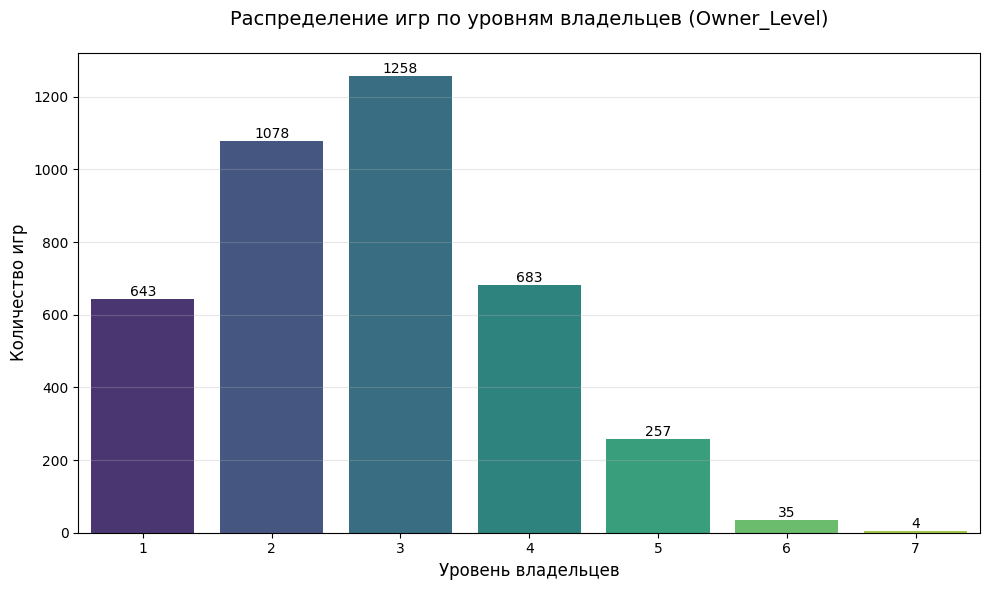

In [38]:
import seaborn as sns

#print("\nРаспределение созданной целевой переменной 'Owner_Level':")
#print(df_user['Owner_Level'].value_counts().sort_index())

plt.figure(figsize=(10, 6))

ax = sns.countplot(x='Owner_Level', data=df_user, palette='viridis')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.title('Распределение игр по уровням владельцев (Owner_Level)', fontsize=14, pad=20)
plt.xlabel('Уровень владельцев', fontsize=12)
plt.ylabel('Количество игр', fontsize=12)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [39]:
df_user.dropna(subset=['Owner_Level'], inplace=True)

y = df_user['Owner_Level'].astype(int) # Убедимся, что y - это int для CatBoost
# Признаки X - это все колонки, кроме самой целевой переменной 'Owner_Level'
# и исходной 'Estimated owners'.
X = df_user.drop(columns=['Owner_Level', 'Estimated owners'])

In [40]:
categorical_features_names = ['Developers', 'Publishers']
# Убедимся, что эти колонки существуют в X, и получим их индексы
existing_categorical_features_in_X = [col for col in categorical_features_names if col in X.columns]
cat_feature_indices = [X.columns.get_loc(col) for col in existing_categorical_features_in_X if col in X.columns]

constant_cols_to_drop = [col for col in X.columns if X[col].nunique(dropna=False) == 1]
if constant_cols_to_drop:
    print(f"\nУдаление константных колонок из X: {constant_cols_to_drop}")
    X = X.drop(columns=constant_cols_to_drop)
    # Важно: если колонки удалены, нужно пересчитать индексы категориальных признаков
    existing_categorical_features_in_X = [col for col in categorical_features_names if col in X.columns]
    cat_feature_indices = [X.columns.get_loc(col) for col in existing_categorical_features_in_X if col in X.columns]
    if existing_categorical_features_in_X: # Проверяем, остались ли категориальные признаки
         print(f"Новые индексы категориальных признаков: {cat_feature_indices}")
    else:
        print("Все указанные категориальные признаки были удалены или отсутствовали.")
        cat_feature_indices = []



Удаление константных колонок из X: ['Windows', 'Utilities']
Новые индексы категориальных признаков: [14, 15]


In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [47]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

model_mc_clf = CatBoostClassifier(
    iterations=250,             # Количество итераций
    learning_rate=0.05,         # Скорость обучения
    depth=6,                    # Глубина деревьев
    loss_function='MultiClass', # Функция потерь для многоклассовой классификации
    eval_metric='Accuracy',     # Метрика для оценки на валидационной выборке (можно также 'MultiClassLogloss')
    cat_features=cat_feature_indices,
    random_state=42,
    verbose=100,                # Выводить информацию каждые 100 итераций
    early_stopping_rounds=50    # Ранняя остановка, если улучшений нет на eval_set
)

model_mc_clf.fit(X_train, y_train,
                 eval_set=(X_test, y_test),
                 plot=False) # Установите plot=True для визуализации процесса обучения в Jupyter

# 8. Предсказание и оценка модели
y_pred_mc_clf = model_mc_clf.predict(X_test)
# y_pred_proba_mc_clf = model_mc_clf.predict_proba(X_test) # Вероятности для каждого класса

accuracy_mc = accuracy_score(y_test, y_pred_mc_clf)
print(f"\nТочность модели (Accuracy) на тестовой выборке: {accuracy_mc:.4f}")

0:	learn: 0.5888087	test: 0.5673401	best: 0.5673401 (0)	total: 12.8ms	remaining: 3.18s
100:	learn: 0.7216606	test: 0.7003367	best: 0.7003367 (100)	total: 1.24s	remaining: 1.82s
200:	learn: 0.7581227	test: 0.7146465	best: 0.7180135 (195)	total: 2.33s	remaining: 569ms
249:	learn: 0.7761733	test: 0.7171717	best: 0.7222222 (217)	total: 2.88s	remaining: 0us

bestTest = 0.7222222222
bestIteration = 217

Shrink model to first 218 iterations.

Точность модели (Accuracy) на тестовой выборке: 0.7222


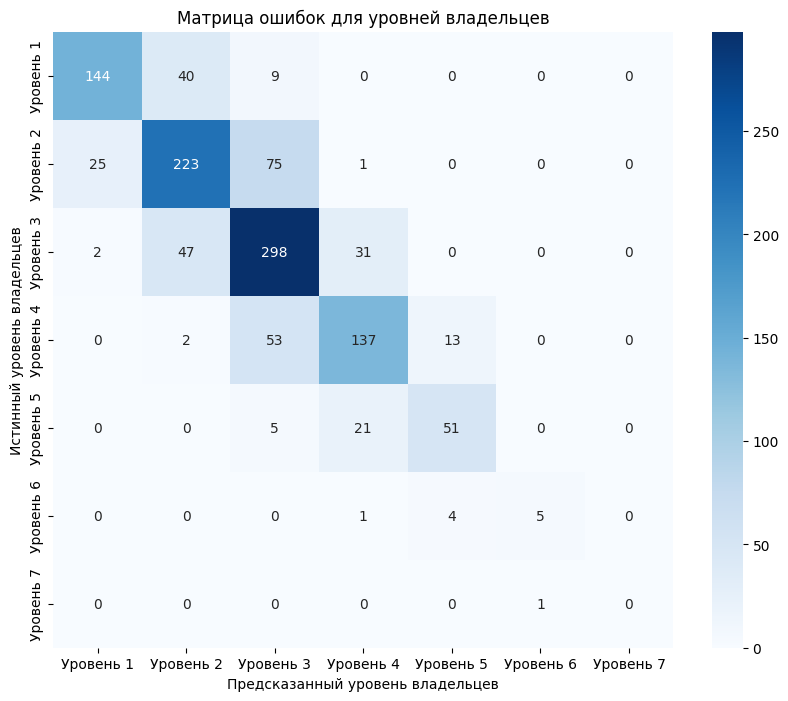

In [48]:
class_labels_for_report = sorted(y.unique())
target_names_for_report = [f'Уровень {i}' for i in class_labels_for_report]

cm_mc = confusion_matrix(y_test, y_pred_mc_clf, labels=class_labels_for_report)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_mc, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names_for_report,
            yticklabels=target_names_for_report)
plt.xlabel("Предсказанный уровень владельцев")
plt.ylabel("Истинный уровень владельцев")
plt.title("Матрица ошибок для уровней владельцев")
plt.show()